In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from collections import Counter

label_map = {
    "Low viral": 0,
    "Medium viral": 1,
    "High viral": 2
}

import os
from openai import OpenAI
import json
import pandas as pd
import matplotlib.pyplot as plt

### Test at different levels of prompt engineering

Trial:0
Matched samples: 1573 / 1573

Accuracy: 0.20152574698029244
Weighted F1: 0.19723628832670415

Confusion Matrix (rows=true, cols=pred):
 [[ 59  91 479]
 [ 52 113 622]
 [  4   8 145]]
pred Counter({2: 1246, 1: 212, 0: 115})
true Counter({1: 787, 0: 629, 2: 157})
**************************************************
Trial:1
Matched samples: 1573 / 1573

Accuracy: 0.34901462174189446
Weighted F1: 0.3288411664511932

Confusion Matrix (rows=true, cols=pred):
 [[ 43 310 276]
 [ 43 385 359]
 [  5  31 121]]
pred Counter({2: 756, 1: 726, 0: 91})
true Counter({1: 787, 0: 629, 2: 157})
**************************************************
Trial:2
Matched samples: 1573 / 1573

Accuracy: 0.40368722186904005
Weighted F1: 0.3832523527180975

Confusion Matrix (rows=true, cols=pred):
 [[250 379   0]
 [402 385   0]
 [ 72  85   0]]
pred Counter({1: 849, 0: 724})
true Counter({1: 787, 0: 629, 2: 157})
**************************************************
Trial:3
Matched samples: 1573 / 1573

Accuracy: 0.164

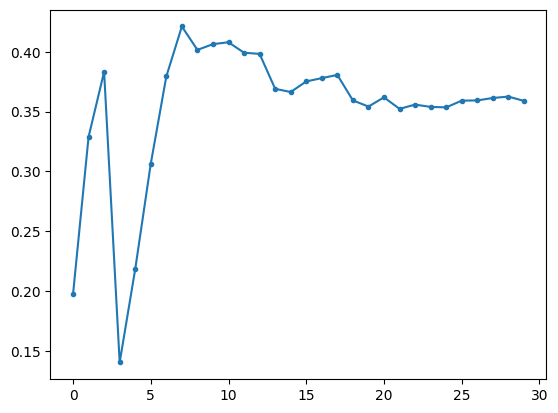

In [2]:
file_name_gt='train_df_test.csv'
file_name_eval='deepseek-chat_test_Text_labels.csv'
f1s=[]
for trial_num in range(0,40):
    print(f'Trial:{trial_num}')
    file_preds=f'Out/trial{trial_num}/{file_name_eval}'
    left_on='ID'
    if not os.path.isfile(file_preds):
        break
    df_preds=pd.read_csv(file_preds)
    if 'ViralityLabel' in df_preds.columns:
        df_preds["label"]=df_preds["ViralityLabel"]
        df_preds=df_preds.drop(columns=['ViralityLabel'])        
    df_preds["y_pred"] = pd.to_numeric(df_preds["label"], errors="coerce")


    df_gt=pd.read_csv(file_name_gt)
    df_gt["y_true"] = df_gt["ViralityLabel"].map(label_map)

    df_eval = df_gt.merge(
        df_preds[["ID", "y_pred"]],
        left_on=left_on,
        right_on="ID",
        how="inner"
    )

    # Drop rows with missing labels
    df_eval = df_eval.dropna(subset=["y_true", "y_pred"])
    df_eval["y_true"] = df_eval["y_true"].astype(int)
    df_eval["y_pred"] = df_eval["y_pred"].astype(int)

    print("Matched samples:", len(df_eval), "/", len(df_gt))


    # -----------------------------
    # Metrics
    # -----------------------------
    y_true = df_eval["y_true"].values
    y_pred = df_eval["y_pred"].values

    print("\nAccuracy:", accuracy_score(y_true, y_pred))
    #print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
    print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))
    f1s.append(f1_score(y_true, y_pred, average="weighted"))

    #print("\nMacro Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
    #print("Macro Recall:", recall_score(y_true, y_pred, average="macro", zero_division=0))

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    print("\nConfusion Matrix (rows=true, cols=pred):\n", cm)

    # -----------------------------
    # Full classification report
    # -----------------------------
    # print("\nClassification Report:\n")
    # print(classification_report(
    #     y_true,
    #     y_pred,
    #     labels=[0, 1, 2],
    #     target_names=["Low viral (0)", "Medium viral (1)", "High viral (2)"],
    #     digits=4,
    #     zero_division=0
    # ))

    print('pred',Counter(y_pred))   
    print('true',Counter(y_true))    
    print('*'*50)
plt.plot(f1s,marker='.')
    

Trial:0
Matched samples: 118 / 118

Accuracy: 0.23728813559322035
Weighted F1: 0.24326152474537505
Counter({2: 94, 1: 16, 0: 8})
**************************************************
Trial:1
Matched samples: 118 / 118

Accuracy: 0.4067796610169492
Weighted F1: 0.40631672948591874
Counter({2: 59, 1: 50, 0: 9})
**************************************************
Trial:2
Matched samples: 118 / 118

Accuracy: 0.3813559322033898
Weighted F1: 0.35686841136870356
Counter({0: 69, 1: 49})
**************************************************
Trial:3
Matched samples: 118 / 118

Accuracy: 0.1864406779661017
Weighted F1: 0.18144748889037762
Counter({2: 103, 0: 8, 1: 7})
**************************************************
Trial:4
Matched samples: 118 / 118

Accuracy: 0.22033898305084745
Weighted F1: 0.22755044390637608
Counter({2: 93, 1: 16, 0: 9})
**************************************************
Trial:5
Matched samples: 118 / 118

Accuracy: 0.3389830508474576
Weighted F1: 0.35395126446911646
Counter({2:

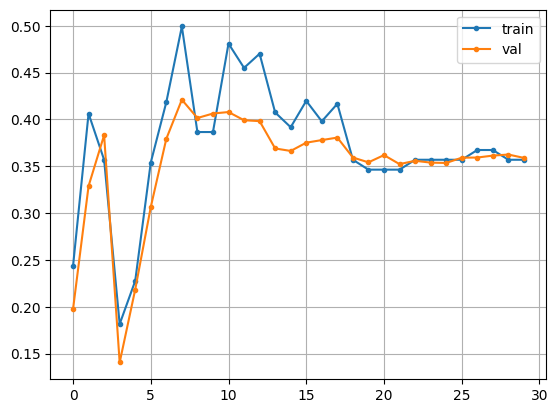

In [4]:
file_name_gt='train_df_train.csv'
file_name_eval='deepseek-chat_train_Text_labels.csv'
train_f1s=[]
for trial_num in range(0,40):
    print(f'Trial:{trial_num}')
    file_preds=f'Out/trial{trial_num}/{file_name_eval}'
    left_on='ID'
    if not os.path.isfile(file_preds):
        break
    df_preds=pd.read_csv(file_preds)
    if 'ViralityLabel' in df_preds.columns:
        df_preds["label"]=df_preds["ViralityLabel"]
        df_preds=df_preds.drop(columns=['ViralityLabel'])        
    df_preds["y_pred"] = pd.to_numeric(df_preds["label"], errors="coerce")


    df_gt=pd.read_csv(file_name_gt)
    df_gt["y_true"] = df_gt["ViralityLabel"].map(label_map)

    df_eval = df_gt.merge(
        df_preds[["ID", "y_pred"]],
        left_on=left_on,
        right_on="ID",
        how="inner"
    )

    # Drop rows with missing labels
    df_eval = df_eval.dropna(subset=["y_true", "y_pred"])
    df_eval["y_true"] = df_eval["y_true"].astype(int)
    df_eval["y_pred"] = df_eval["y_pred"].astype(int)

    print("Matched samples:", len(df_eval), "/", len(df_gt))


    # -----------------------------
    # Metrics
    # -----------------------------
    y_true = df_eval["y_true"].values
    y_pred = df_eval["y_pred"].values

    print("\nAccuracy:", accuracy_score(y_true, y_pred))
    print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))
    train_f1s.append(f1_score(y_true, y_pred, average="weighted"))

    

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    

    print(Counter(y_pred))    
    print('*'*50)
plt.plot(train_f1s,marker='.',label='train')
plt.plot(f1s,marker='.',label='val')    
plt.legend()
plt.grid(True)          # enables grid for both axes
plt.show()